In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from inputs_for_plots import *

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

def load_and_calculate_errors(file_path, estimated_col, true_col):
    """Loads data and calculates errors."""
    data = pd.read_csv(file_path, header=0, index_col=0)
    return calc_erros(data[estimated_col], data[true_col])

def gather_statistics(errors, rmse, mae, std):
    """Extracts RMSE, MAE, and STD from error dictionary and appends to lists."""
    rmse.append(errors["RMSE"])
    mae.append(errors["MAE"])
    std.append(errors["STD"])

def prepare_error_dataframe(ols_est, errors_list, column_names):
    """Creates a DataFrame with all error values in a long format."""
    df_list = [pd.DataFrame(np.abs(ols_est), columns=["Biased OLS"])]
    for errors, col_name in zip(errors_list, column_names):
        df_list.append(pd.DataFrame(errors["error"], columns=[col_name]))
    return pd.concat(df_list, axis=1)

def plot_errors(err, rmse, mae, std, ax, level):
    """Creates boxplots and adds legend with RMSE, MAE, and STD."""
    df_long = err.melt(var_name="variable", value_name="value").dropna()
    sns.boxplot(data=df_long, y="value", hue="variable", ax=ax)
    
    ax.set_title(f"Confounding level {level}", fontsize=20)
    ax.set_ylabel("Absolute deviation from true treatment effect", fontsize=20)
    ax.set_xlabel("Methods", fontsize=20)
    ax.tick_params(axis='both', which='major', labelsize=20)
    
    palette = sns.color_palette(n_colors=err.shape[1])
    handles = [
        mpatches.Patch(color=palette[i], label=f"RMSE = {rmse[i]:.2f}, MAE = {mae[i]:.2f}, Std = {std[i]:.2f}  : {err.columns[i]}")
        for i in range(len(err.columns))
    ]
    ax.legend(handles=handles, loc="upper center", fontsize=15)

from sklearn.linear_model import LinearRegression
def calculate_ols_estimate(path = "data_generation/different_confounding_levels/data/", name = "data_obs_large_conf_3_"):
    ols_est = []
    for i in range(100):
        data = pd.read_csv(f"../{path}{name}{i}.csv")
        est = LinearRegression()
        # regress last column on all other columns
        est.fit(data.iloc[:, :-1], data.iloc[:, -1])
        ols_est.append(est.coef_[-1])

    return ols_est

def calc_erros(est, true):
    err = est-true
    rmse = np.sqrt(np.mean(err**2))
    mae = np.mean(np.abs(err))
    std = np.std(err)
    return {"RMSE": rmse, "MAE": mae, "STD": std, "error": np.abs(err)}


def get_true_treatment_effect(path, name):
    true = []
    for i in range(100):
        data = pd.read_csv(f"../{path}{name}{i}.csv")
        true.append(data.iloc[-1, -2])
    return true


# Plot increase in confounding

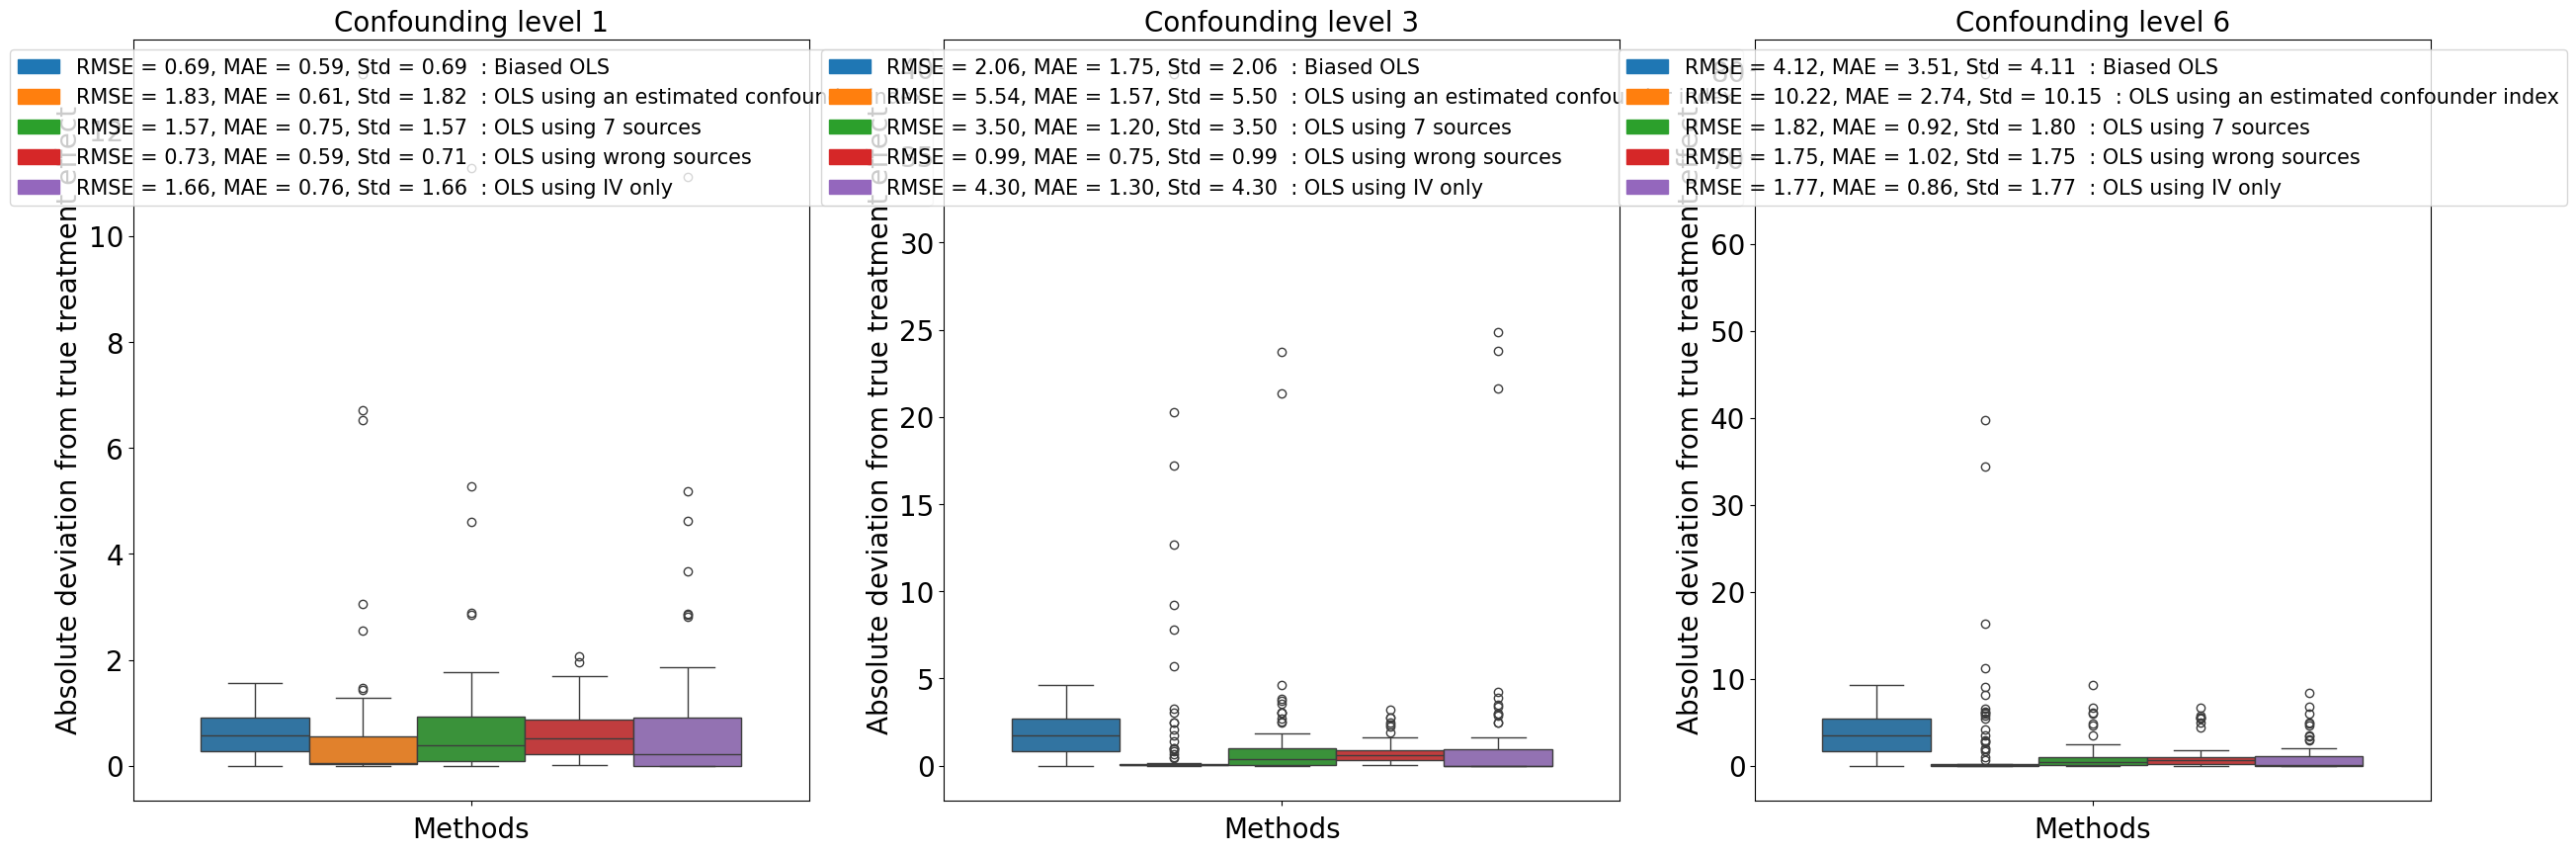

In [13]:
def main_plot(confounder_levels):
    """Generates plots for different confounder levels."""
    method_summary = {}
    fig, axes = plt.subplots(1, len(confounder_levels), figsize=(30, 10))
    
    for i, level in enumerate(confounder_levels):
        rmse, mae, std = [], [], []
        true_treatment_effect = get_true_treatment_effect(path=f"data_generation/different_confounding_levels/data/", name=f"true_mixing_large_conf_{level}_")
        ols_est = calculate_ols_estimate(path=f"data_generation/different_confounding_levels/data/", name=f"data_obs_large_conf_{level}_")
        ols_est = np.array(ols_est) - np.array(true_treatment_effect)
        gather_statistics({"RMSE": np.sqrt(np.mean(np.array(ols_est)**2)), "MAE": np.mean(np.abs(ols_est)), "STD": np.std(ols_est)}, rmse, mae, std)
        
        errors_confounder = load_and_calculate_errors(f"../treatment_effect_estimation/treatment_effect_estimations/true_sources_confounder_source_cn_{level}.csv", "estimated_treatment_using_confounder_source", "true_treatment_effect")
        gather_statistics(errors_confounder, rmse, mae, std)
        
        errors_7_sources = load_and_calculate_errors(f"../treatment_effect_estimation/treatment_effect_estimations/true_sources_7_sources_cn_{level}.csv", "estimated_treatment_on_sources", "true_treatment_effect")
        gather_statistics(errors_7_sources, rmse, mae, std)
        
        errors_nonsense = load_and_calculate_errors(f"../treatment_effect_estimation/treatment_effect_estimations/true_sources_7_sources_nonsense_cn_{level}.csv", "mistaken_scheme", "true_treatment_effect")
        gather_statistics(errors_nonsense, rmse, mae, std)

        errors_iv_only = load_and_calculate_errors(f"../treatment_effect_estimation/treatment_effect_estimations/true_sources_iv_only_cn_{level}.csv", "iv_only_effect", "true_treatment_effect")
        gather_statistics(errors_iv_only, rmse, mae, std)
        
        err = prepare_error_dataframe(ols_est, [errors_confounder, errors_7_sources, errors_nonsense,errors_iv_only ], ["OLS using an estimated confounder index", "OLS using 7 sources", "OLS using wrong sources", "OLS using IV only"])
        cases = {col: 100 - err[col].isna().sum() for col in err.columns}
        method_summary[level] =  {"cases": cases,"rmse": rmse, "mae": mae, "std": std}
        plot_errors(err, rmse, mae, std, axes[i], level)
    
    plt.show()
    return method_summary

# Example usage
confounder_levels = [1, 3, 6]
method_summary = main_plot(confounder_levels)


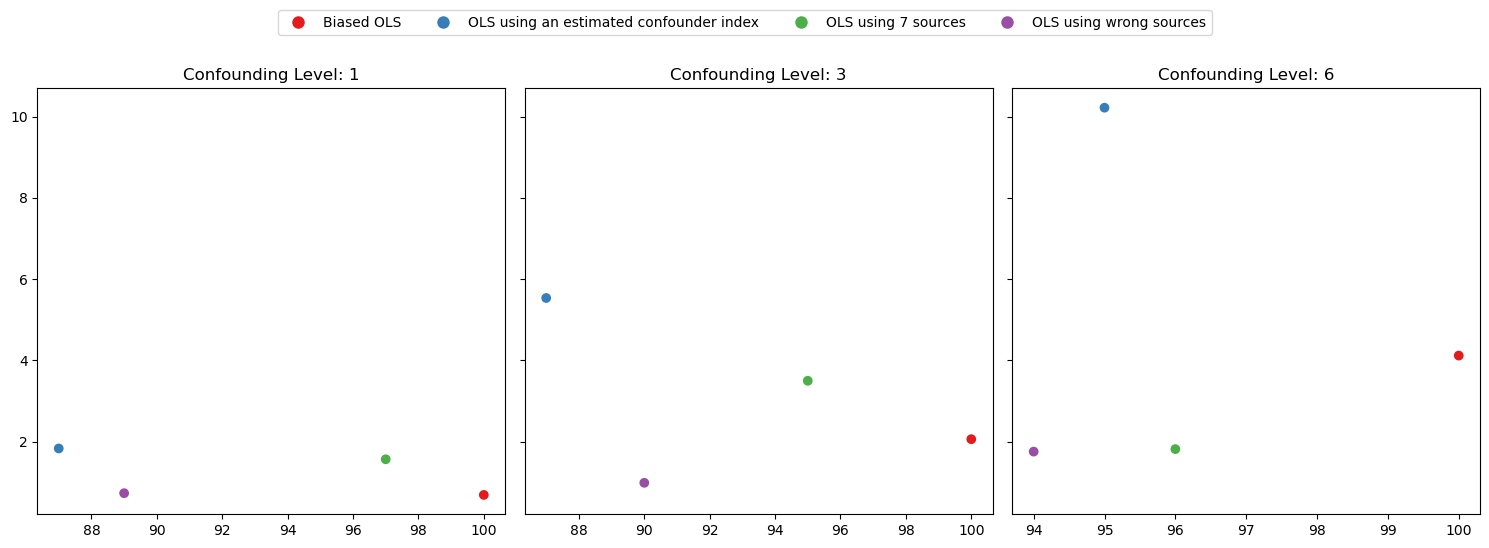

In [135]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

# Define the color palette
palette = sns.color_palette("Set1", 4)

# Iterate over the confounding levels and plot the data
for i, level in enumerate(confounder_levels):
    methods = method_summary[level]["cases"].keys()
    cases = method_summary[level]["cases"].values()
    rmse = method_summary[level]["rmse"]

    # Scatter plot
    ax[i].scatter(cases, rmse, c=palette, label=methods)
    
    # Set the title with confounding level
    ax[i].set_title(f"Confounding Level: {level}")

# Create the legend handles
legend_labels = list(methods)
legend_colors = palette[:len(legend_labels)]
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10) for color in legend_colors]

# Add the legend above all subplots
fig.legend(handles, legend_labels, loc='upper center', ncol=len(legend_labels), bbox_to_anchor=(0.5, 1.1))
plt.tight_layout()
# Show the plot
plt.show()